In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import scipy
import re
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np
from players import non_meta_strategies, meta_strategy_classes

# List of result files to visualize
types = ['standard', 'noisy', 'probabilistic', 'prob_noisy']
dfs = []
normalized_r_summs = []

def extract_base_name(name):
    # Remove anything after ':' or '(' or '[' (for meta strategies and parameterized names)
    return re.split(r'[:\(\[]', name)[0].strip()

def remove_highly_correlated(df, threshold=0.90):    
    # Compute absolute correlation matrix
    corr_matrix = df.corr().abs()
    columns = corr_matrix.columns
    to_remove = set()
    
    # Identify columns to remove
    for i in range(len(columns)):
        for j in range(i + 1, len(columns)):
            col_i, col_j = columns[i], columns[j]
            if col_i in to_remove or col_j in to_remove:
                continue
            if corr_matrix.iloc[i, j] > threshold:
                to_remove.add(col_j)
    
    # Drop highly correlated columns and combine with non-numeric data
    print(list(to_remove))
    result_df = df.drop(columns=list(to_remove))
    return result_df

strategy_meta = []
for s in non_meta_strategies + meta_strategy_classes:
    player = s()
    meta = player.classifier.copy()
    meta['BaseName'] = extract_base_name(player.name)
    strategy_meta.append(meta)
meta_df = pd.DataFrame(strategy_meta)
meta_df['uses_length'] = meta_df['makes_use_of'].apply(lambda x: 'length' in x if isinstance(x, set) else False)
meta_df['uses_game'] = meta_df['makes_use_of'].apply(lambda x: 'game' in x if isinstance(x, set) else False)
meta_df = meta_df.drop('makes_use_of', axis=1)


['coop_vs_mean', 'min_vs_coop', 'coop_vs_max', 'DD_rate']
           feature        VIF
0   Initial_C_rate   8.735513
1          CC_rate  41.265279
2          CD_rate  20.305929
3          DC_rate  13.765362
4     CC_to_C_rate  20.261639
5     CD_to_C_rate   6.870331
6     DC_to_C_rate   4.157041
7     DD_to_C_rate   4.766507
8                R  41.480721
9                S   1.195466
10               T  57.415028
11               P   5.064651
12           noise   3.748513
13        prob_end   4.031055
14     repetitions   5.465611
15           turns   4.190851
16    n_strategies  14.319683
17        coop_min   2.579107
18  coop_vs_median  31.582296
19    memory_depth   2.791283
20      stochastic   2.056831
21     uses_length   3.262134
22       uses_game   2.867854
                            OLS Regression Results                            
Dep. Variable:        normalized_rank   R-squared:                       0.775
Model:                            OLS   Adj. R-squared:         

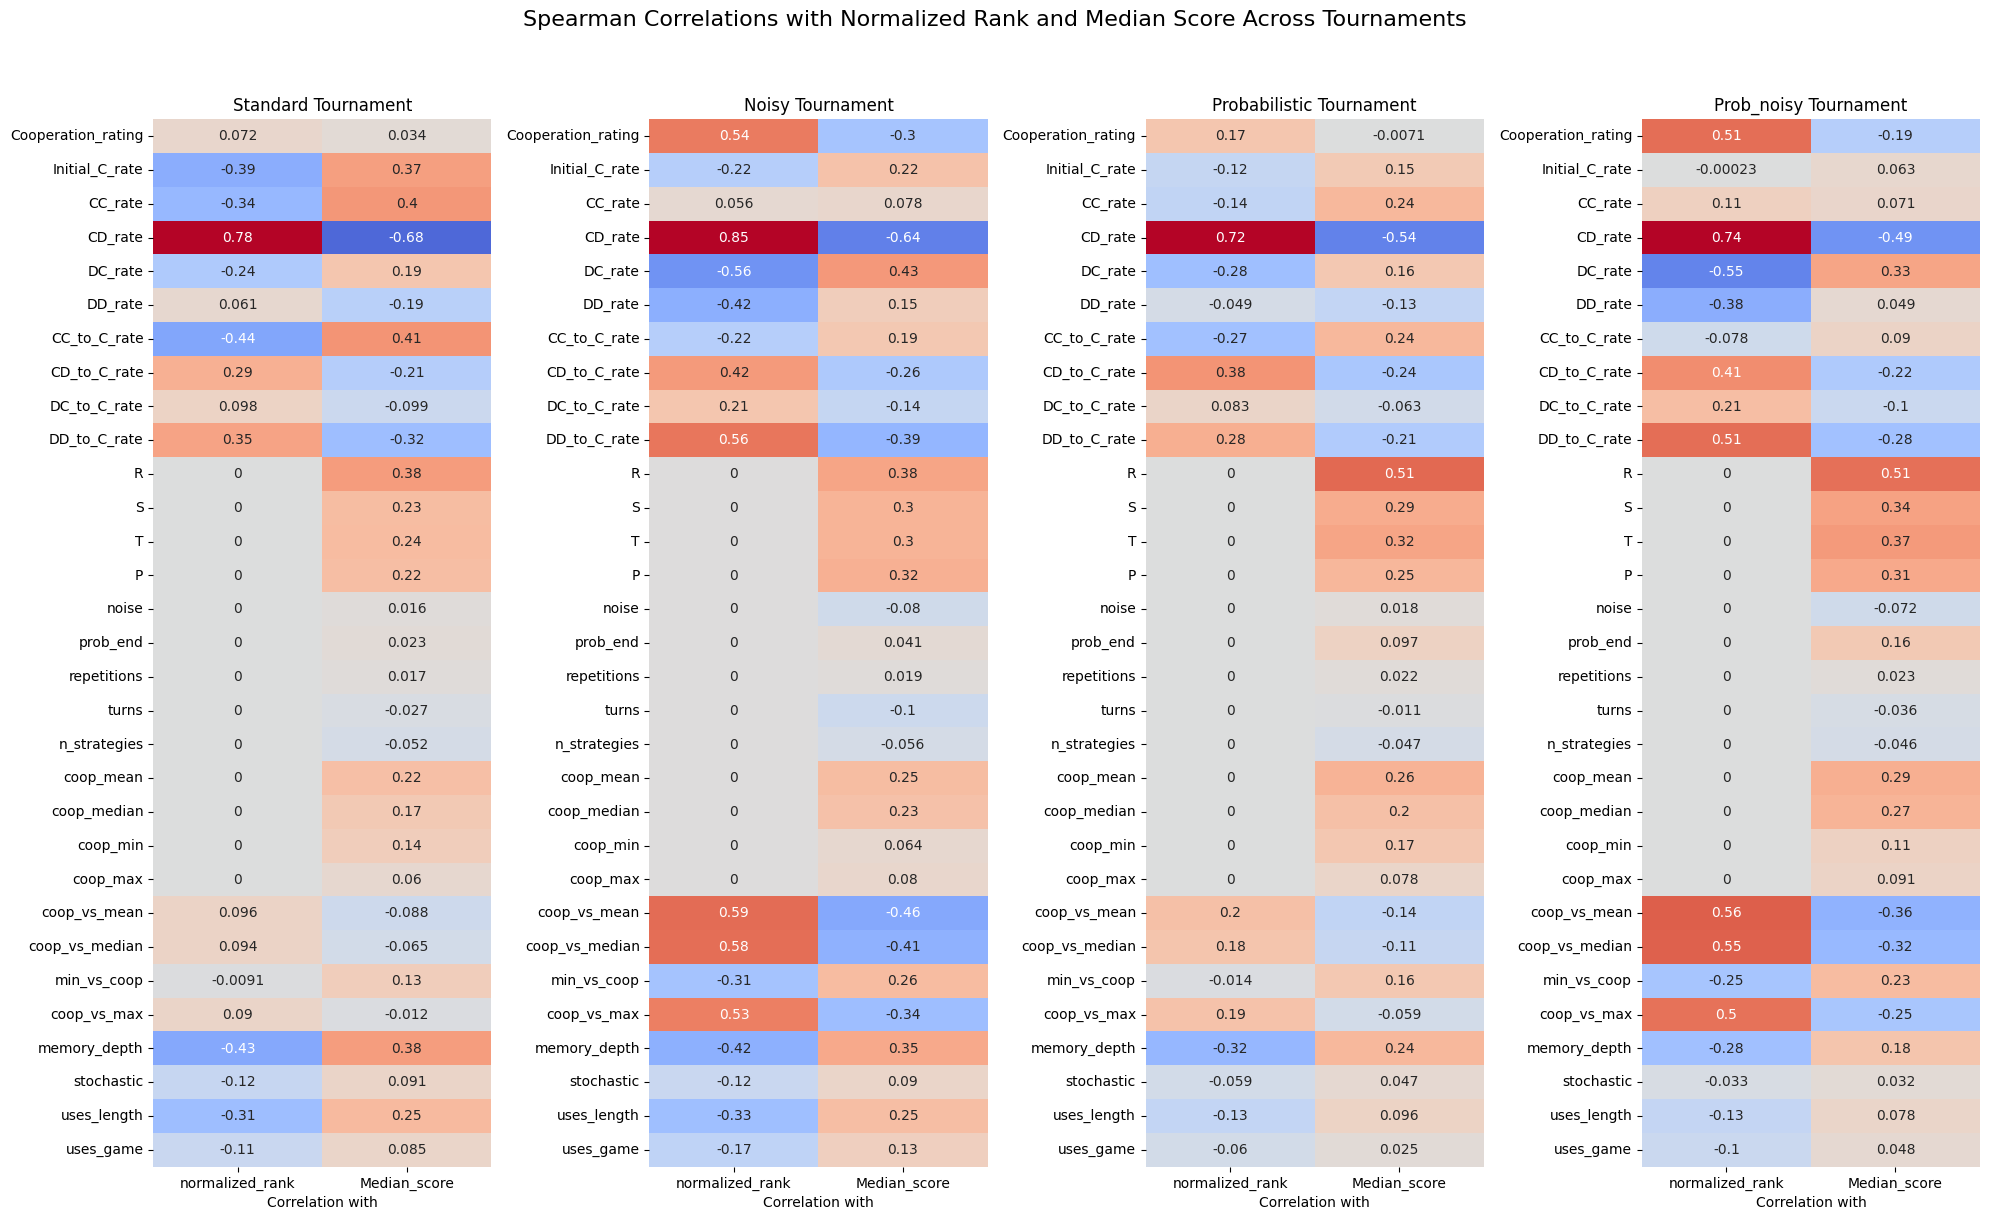

In [20]:
num_types = len(types)

# Define the list of parameter columns you want to correlate with normalized_rank
param_columns = ['Cooperation_rating', 'Initial_C_rate', 'CC_rate', 'CD_rate', 'DC_rate', 'DD_rate', 'CC_to_C_rate',
                     'CD_to_C_rate', 'DC_to_C_rate', 'DD_to_C_rate', 'R', 'S', 'T', 'P', 'noise', 'prob_end',
                     'repetitions', 'turns', 'n_strategies', 'coop_mean', 'coop_median', 'coop_min', 'coop_max',
                     'coop_vs_mean', 'coop_vs_median', 'min_vs_coop', 'coop_vs_max', 'memory_depth', 'stochastic',
                     'uses_length', 'uses_game']

fig, axes = plt.subplots(1, num_types, figsize=(5 * num_types, max(6, len(param_columns) * 0.4)), squeeze=False)

for i, t in enumerate(types):
    filename = os.path.join("csv", f"{t}_aggregated.csv")
    if not os.path.exists(filename):
        print(f"File {filename} not found, skipping.")
        continue
    df = pd.read_csv(filename)
    df['tournament_type'] = t
    df['BaseName'] = df['Name'].apply(extract_base_name)

    # Calculate normalized ranks
    df['normalized_rank'] = df['Rank'] / (df['n_strategies'] - 1)
    
    # Merge strategy metadata
    df = df.merge(meta_df[['BaseName', 'memory_depth', 'stochastic', 'uses_length', 'uses_game']], on='BaseName', how='left')

    # create dataframe with tournament cooperation stats
    coop_stats = df.groupby('run')['Cooperation_rating'].agg(
        coop_mean='mean',
        coop_median='median',
        coop_min='min',
        coop_max='max'
    ).reset_index()

    df = df.merge(coop_stats, on='run', how='left')

    df['memory_depth'] /= df['turns']
    df['memory_depth'] = df['memory_depth'].replace(np.inf, 1)

    df['coop_vs_mean'] = df['Cooperation_rating'] / df['coop_mean']
    df['coop_vs_median'] = df['Cooperation_rating'] / df['coop_median']
    df['min_vs_coop'] = df['coop_min'] / df['Cooperation_rating'] # inverse to avoid dividing by 0
    df['coop_vs_max'] = df['Cooperation_rating'] / df['coop_max']
    df = df.fillna(0)

    if param_columns:
        correlations = df[param_columns + ['normalized_rank', 'Median_score']].corr(method='spearman')[['normalized_rank', 'Median_score']].drop(['normalized_rank', 'Median_score'])
        ax = axes[0, i]
        sns.heatmap(correlations, annot=True, cmap='coolwarm', center=0, ax=ax, cbar=False)
        ax.set_title(f"{t.capitalize()} Tournament")
        ax.set_ylabel('')  # Remove y-axis label to save space, optional
        ax.set_xlabel('Correlation with')
    else:
        print(f"No matching parameter columns found in {filename} for correlation.")
        axes[0, i].axis('off')  # Hide the subplot if no data
    
    for col in ['stochastic', 'uses_length', 'uses_game']:
        if col in df.columns:
            df[col] = df[col].astype(int)

    X = df.loc[:, param_columns]
    y = df.loc[:, 'normalized_rank']

    X['coop_vs_median'] = X['coop_vs_median'].replace(np.inf, 1)
    X = remove_highly_correlated(X)
    X = X.drop(['Cooperation_rating', 'coop_mean', 'coop_median', 'coop_max'], axis=1)
    
    vif_data = pd.DataFrame()
    vif_data["feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    print(vif_data) 
    X = sm.add_constant(X)  # Add intercept term

    model = sm.OLS(y, X).fit()
    print(model.summary())

    # results_table = pd.DataFrame({
    # "Variable": model.params.index,
    # "Coeff.": model.params.round(3),
    # "p-value": model.pvalues.apply(lambda x: f"{x:.3f}" if x >= 0.001 else "<0.001"),
    # })

    # latex_table = results_table.to_latex(
    # index=False,
    # caption="OLS Regression Results for Normalized Rank",
    # label="tab:regression",
    # escape=False,  # Allows LaTeX math symbols
    # column_format="lrr",  # Alignment (l=left, r=right, c=center)
    # position="htbp"  # Table placement preference
    # )
    # print(latex_table)  # Copy-paste into your .tex file
    
    dfs.append(df)
    # Plot average score per strategy (original barplot)
    # if 'BaseName' in df.columns and 'normalized_rank' in df.columns:
    #     plt.figure(figsize=(12, 6))
    #     # Group by BaseName only, averaging across all runs/conditions for this tournament type
    #     avg_scores = df.groupby('BaseName')['normalized_rank'].median().sort_values()
    #     sns.barplot(x=avg_scores.index, y=avg_scores.values)
    #     plt.title(f"Median Normalized Rank per Strategy - {t.capitalize()} Tournament")
    #     plt.ylabel("Median Normalized Rank")
    #     plt.xlabel("Strategy")
    #     plt.xticks(rotation=90)
    #     plt.tight_layout()
    #     plt.show()
    #     #plt.savefig(f"graphs/{t}_median_normalized_ranks.png")
    #     plt.close()
    #     print(f"Saved plot: graphs/{t}_median_normalized_ranks.png")
    # else:
    #     print(f"'BaseName' or 'normalized_rank' column not found in {filename}, skipping plot.")

plt.suptitle("Spearman Correlations with Normalized Rank and Median Score Across Tournaments", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [25]:
# Combine all tournament dataframes
combined_df = pd.concat(dfs, ignore_index=True)

# Create a dictionary to store ordered strategy names for each tournament
ranked_names = {}

# For each tournament type, sort strategies by median normalized rank
for t in types:
    ranks = (
        combined_df[combined_df['tournament_type'] == t]
        .groupby('BaseName')['normalized_rank']
        .median()
        .sort_values()
    )
    ranked_names[t.capitalize()] = list(ranks.index)

# Determine the max number of strategies (for row count)
max_len = max(len(v) for v in ranked_names.values())

# Pad shorter lists with empty strings
for k in ranked_names:
    lst = ranked_names[k]
    if len(lst) < max_len:
        ranked_names[k] = lst + [''] * (max_len - len(lst))

# Convert to DataFrame
rank_table = pd.DataFrame(ranked_names)

# Create LaTeX table
latex_table = rank_table.to_latex(
    index=False,
    caption="Strategies Ordered by Median Normalized Rank in Each Tournament Type",
    label="tab:ordered_strategies",
    column_format="l" * len(rank_table.columns),
    position="htbp"
)

print("\nLaTeX Table of Ordered Strategies:\n")
print(latex_table)



LaTeX Table of Ordered Strategies:

\begin{table}[htbp]
\caption{Strategies Ordered by Median Normalized Rank in Each Tournament Type}
\label{tab:ordered_strategies}
\begin{tabular}{llll}
\toprule
Standard & Noisy & Probabilistic & Prob_noisy \\
\midrule
DoubleCrosser & Evolved HMM 5 & Grudger & Defector \\
Evolved HMM 5 & Grudger & Evolved HMM 5 & Grudger \\
Grudger & DoubleCrosser & Evolved FSM 16 & Evolved HMM 5 \\
Evolved FSM 16 & Defector & Defector & Evolved FSM 16 \\
Meta Winner & Meta Winner & DoubleCrosser & Suspicious Tit For Tat \\
Tit For Tat & Evolved FSM 16 & Tit For Tat & Meta Winner \\
Soft Joss & Tit For Tat & Meta Winner & DoubleCrosser \\
Defector & Soft Joss & Soft Joss & Tit For Tat \\
Win-Stay Lose-Shift & Suspicious Tit For Tat & Win-Stay Lose-Shift & Soft Joss \\
GTFT & Win-Stay Lose-Shift & Suspicious Tit For Tat & Win-Stay Lose-Shift \\
Tit For 2 Tats & GTFT & GTFT & Cycler DC \\
Suspicious Tit For Tat & Tit For 2 Tats & Cycler DC & Meta Mixer \\
Meta Mixer &

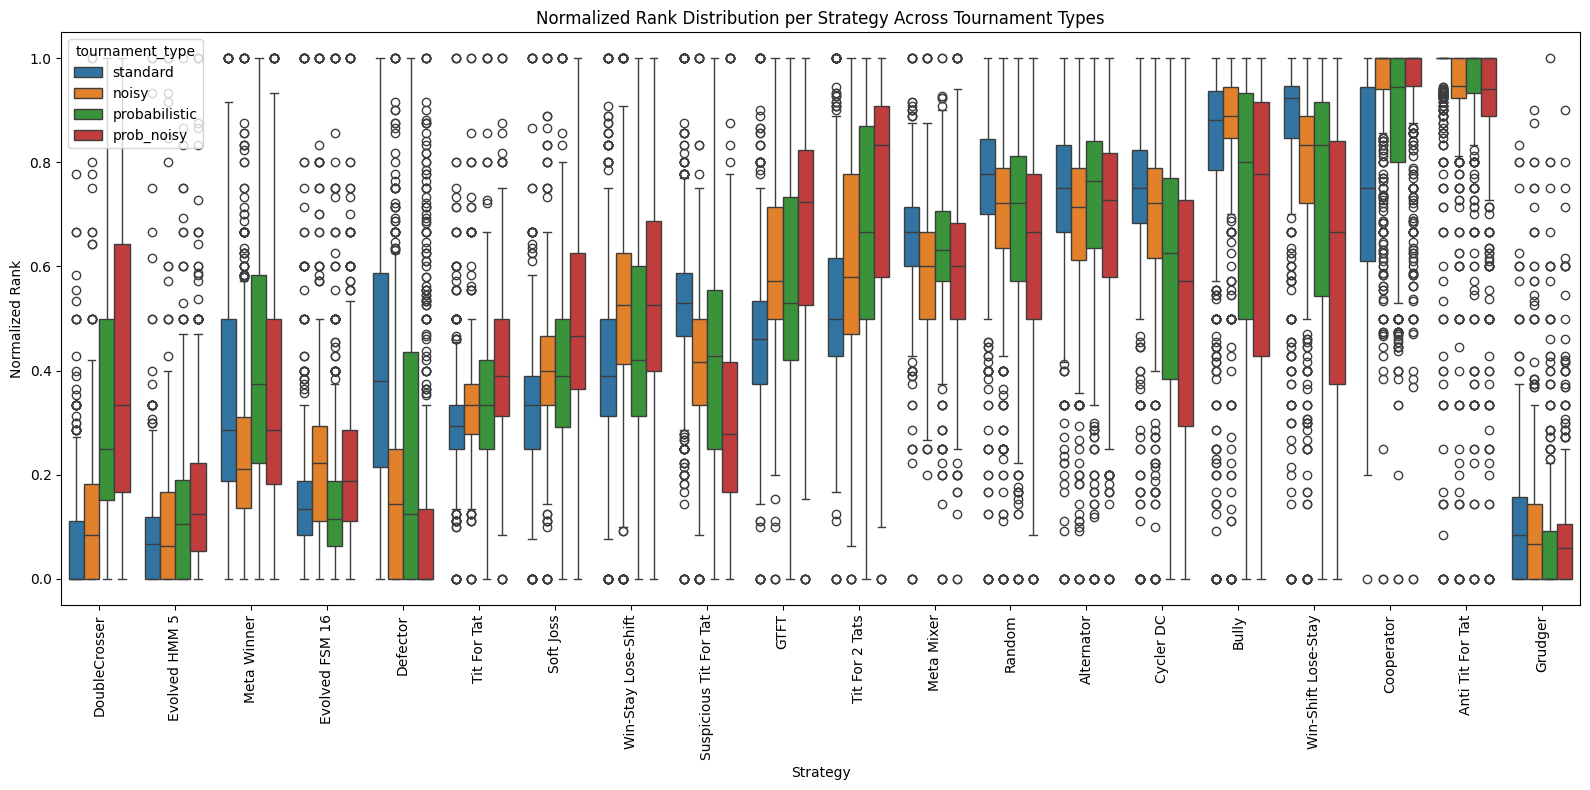

Saved plot: graphs/score_distribution_boxplot.png


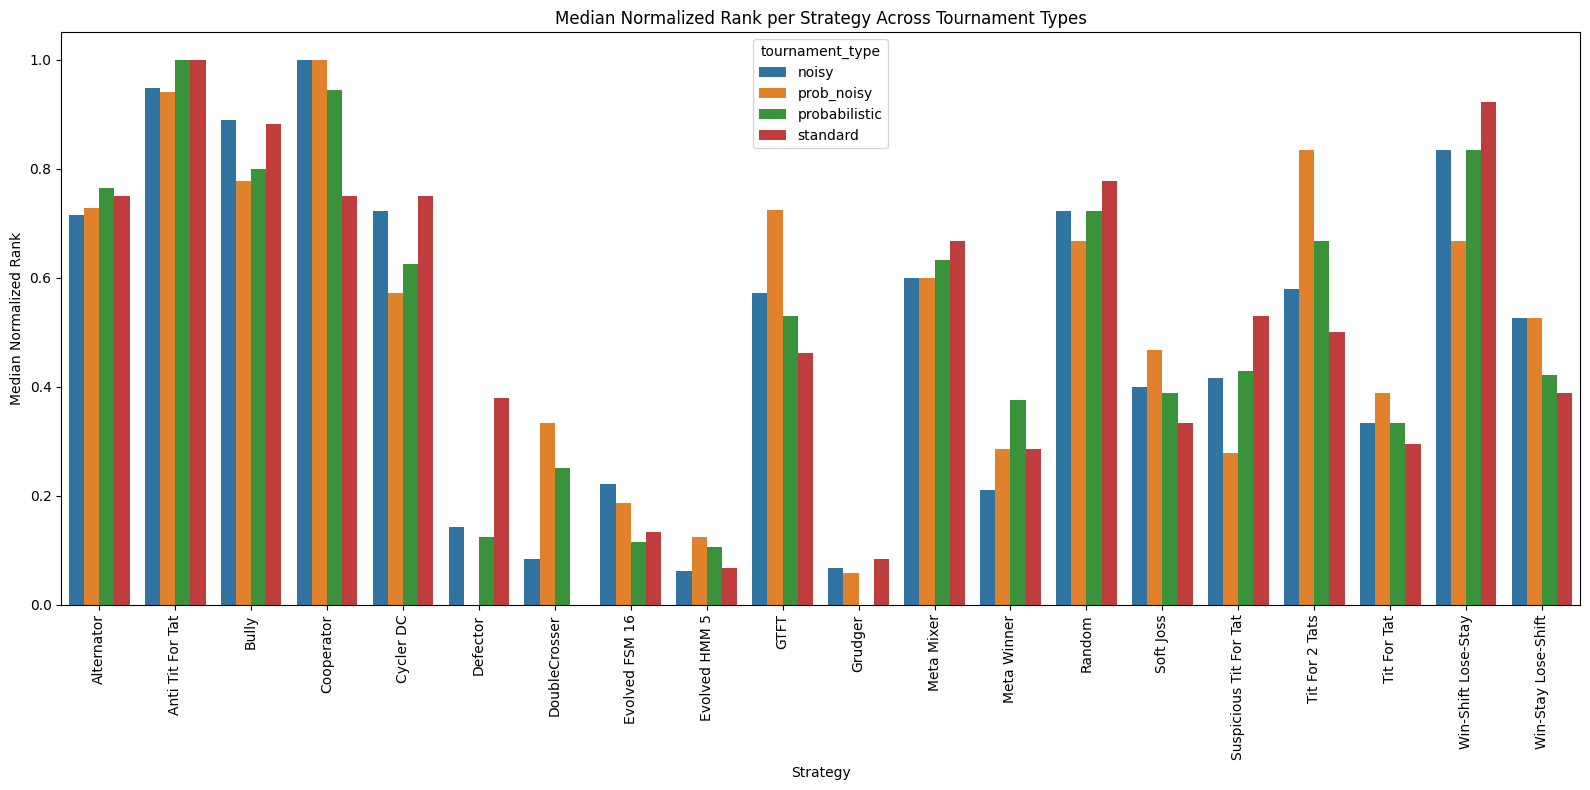

Saved plot: graphs/median_score_comparison.png
\begin{table}
\caption{Median Normalized Rank per Strategy Across Tournament Types}
\label{tab:median_normalized_rank}
\begin{tabular}{lrrrr}
\toprule
tournament_type & noisy & prob_noisy & probabilistic & standard \\
BaseName &  &  &  &  \\
\midrule
Alternator & 0.714000 & 0.727000 & 0.765000 & 0.750000 \\
Anti Tit For Tat & 0.947000 & 0.941000 & 1.000000 & 1.000000 \\
Bully & 0.889000 & 0.778000 & 0.800000 & 0.882000 \\
Cooperator & 1.000000 & 1.000000 & 0.944000 & 0.750000 \\
Cycler DC & 0.722000 & 0.571000 & 0.625000 & 0.750000 \\
Defector & 0.143000 & 0.000000 & 0.125000 & 0.380000 \\
DoubleCrosser & 0.083000 & 0.333000 & 0.250000 & 0.000000 \\
Evolved FSM 16 & 0.222000 & 0.188000 & 0.114000 & 0.133000 \\
Evolved HMM 5 & 0.062000 & 0.125000 & 0.105000 & 0.067000 \\
GTFT & 0.571000 & 0.725000 & 0.529000 & 0.462000 \\
Grudger & 0.067000 & 0.059000 & 0.000000 & 0.083000 \\
Meta Mixer & 0.600000 & 0.600000 & 0.632000 & 0.667000 \\
Meta Wi

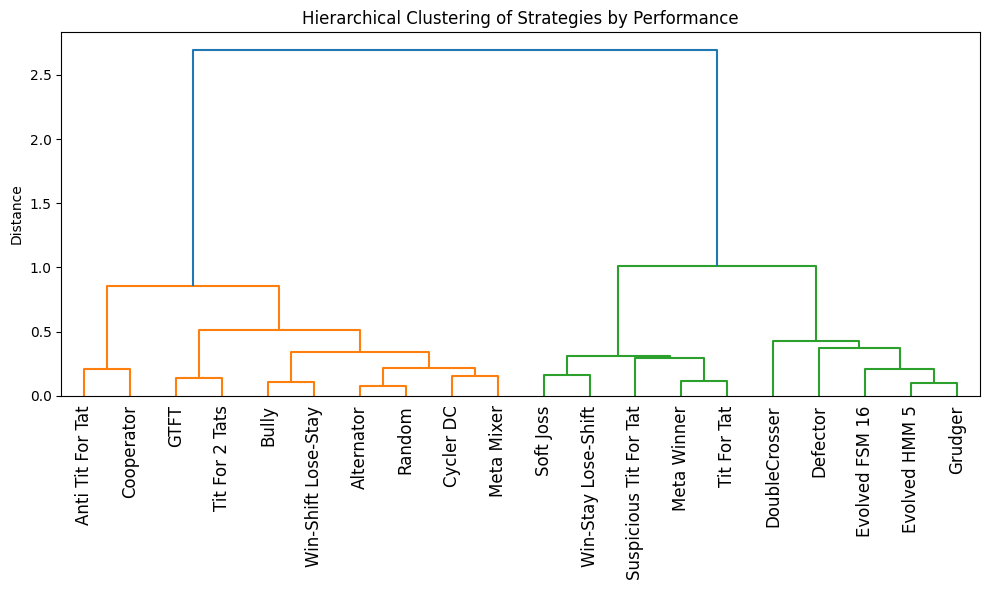

Saved plot: graphs/strategy_clustering_dendrogram.png


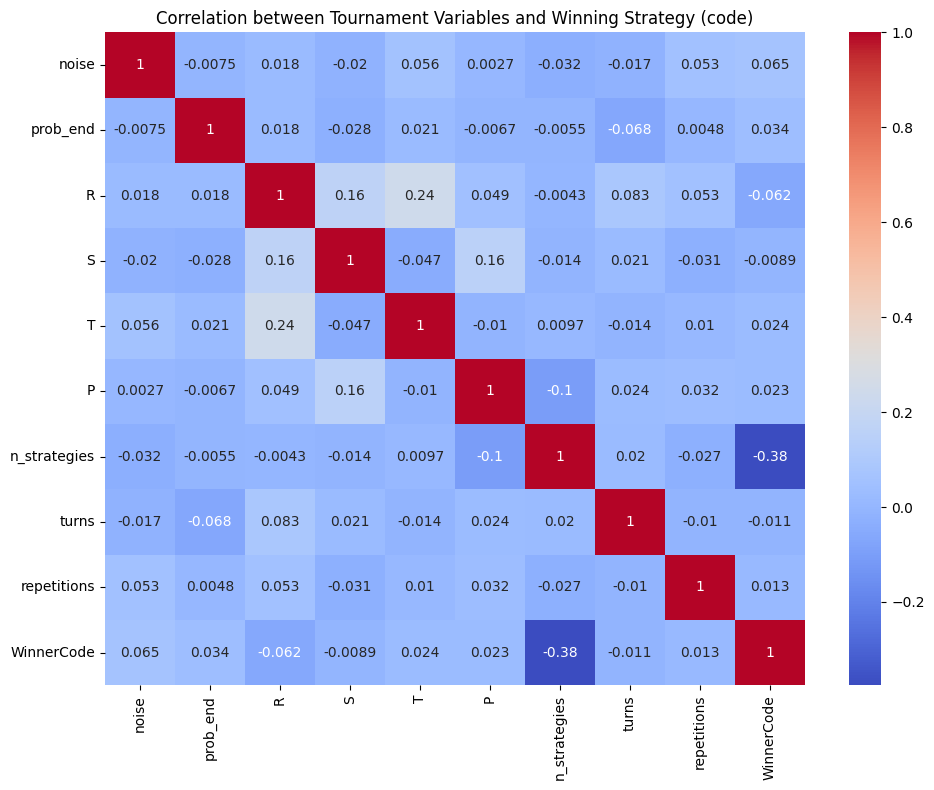

Saved plot: graphs/winner_variable_correlation_heatmap.png


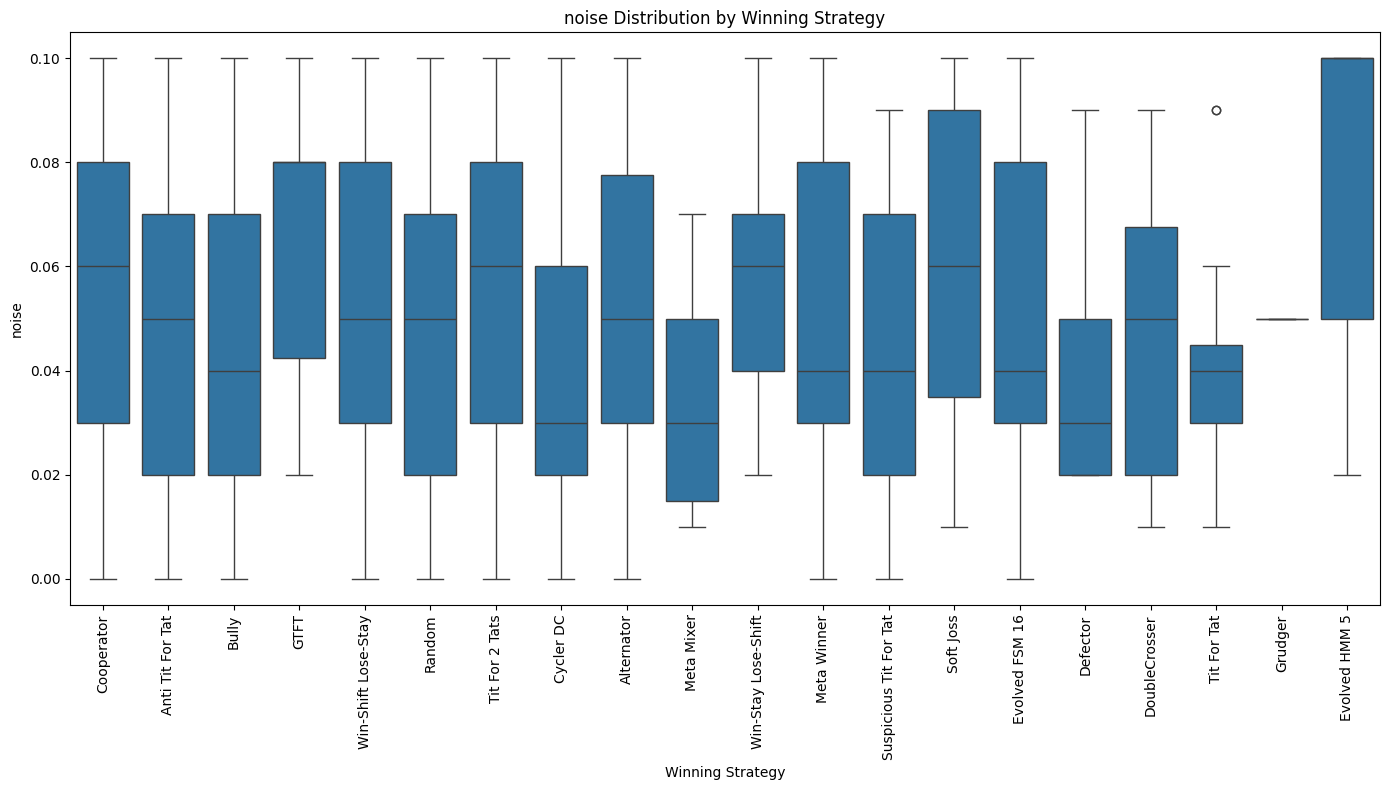

Saved plot: graphs/winner_noise_boxplot.png


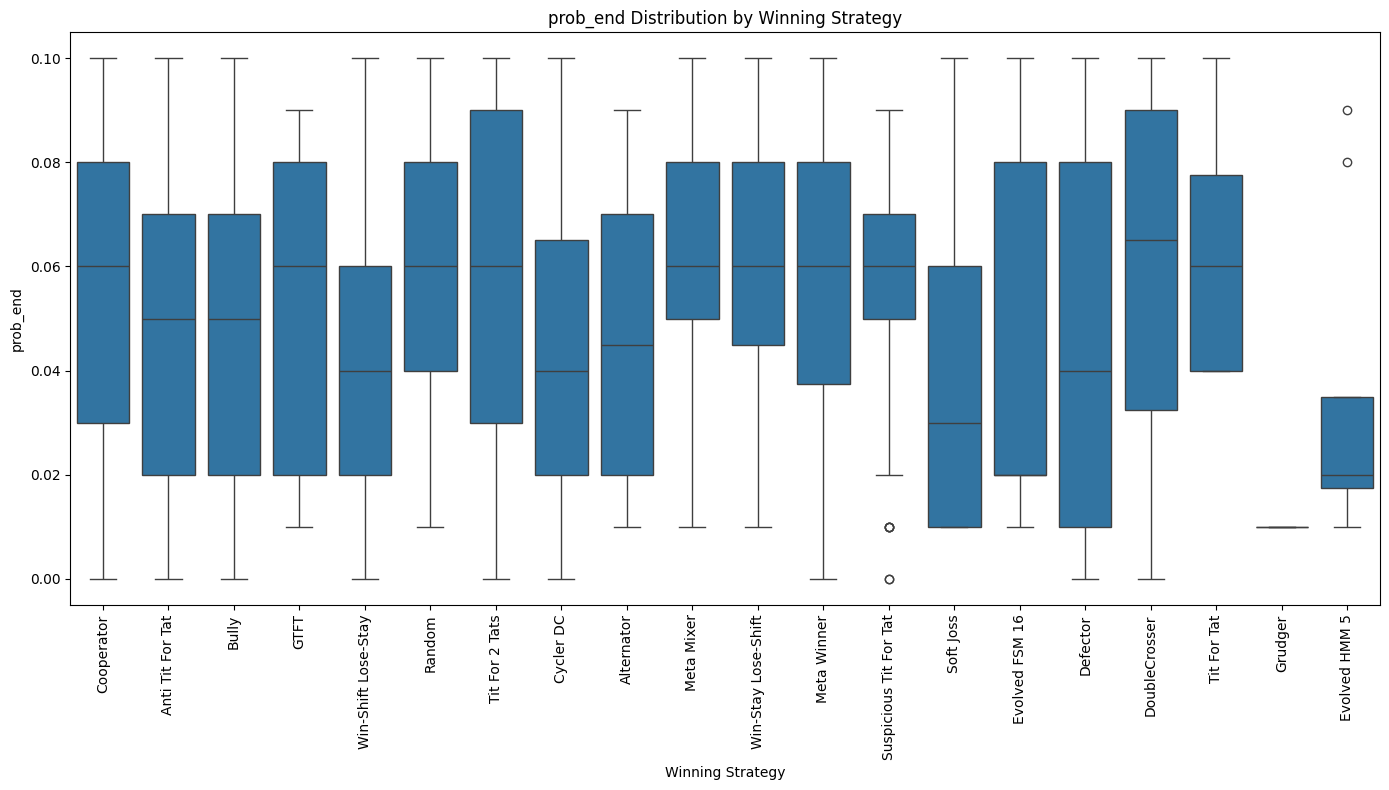

Saved plot: graphs/winner_prob_end_boxplot.png


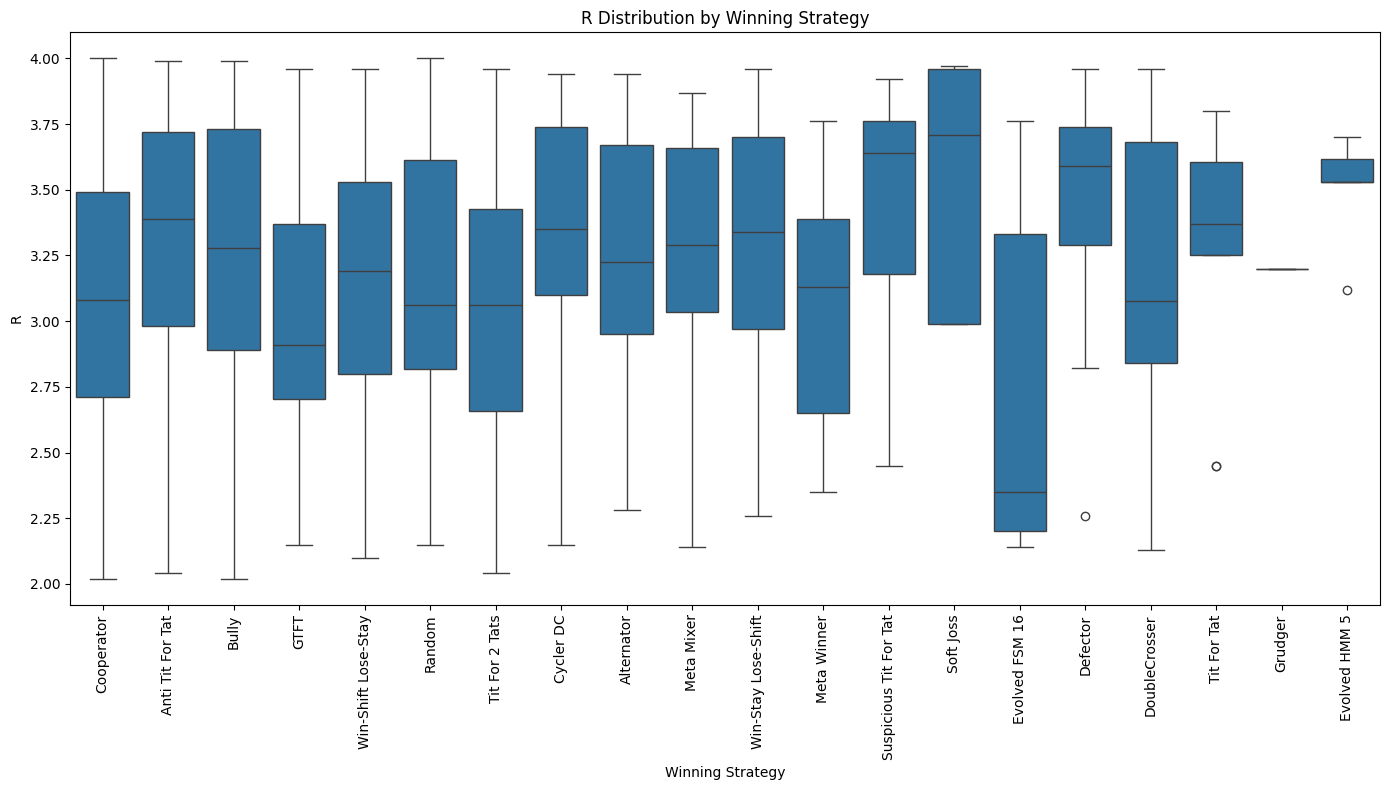

Saved plot: graphs/winner_R_boxplot.png


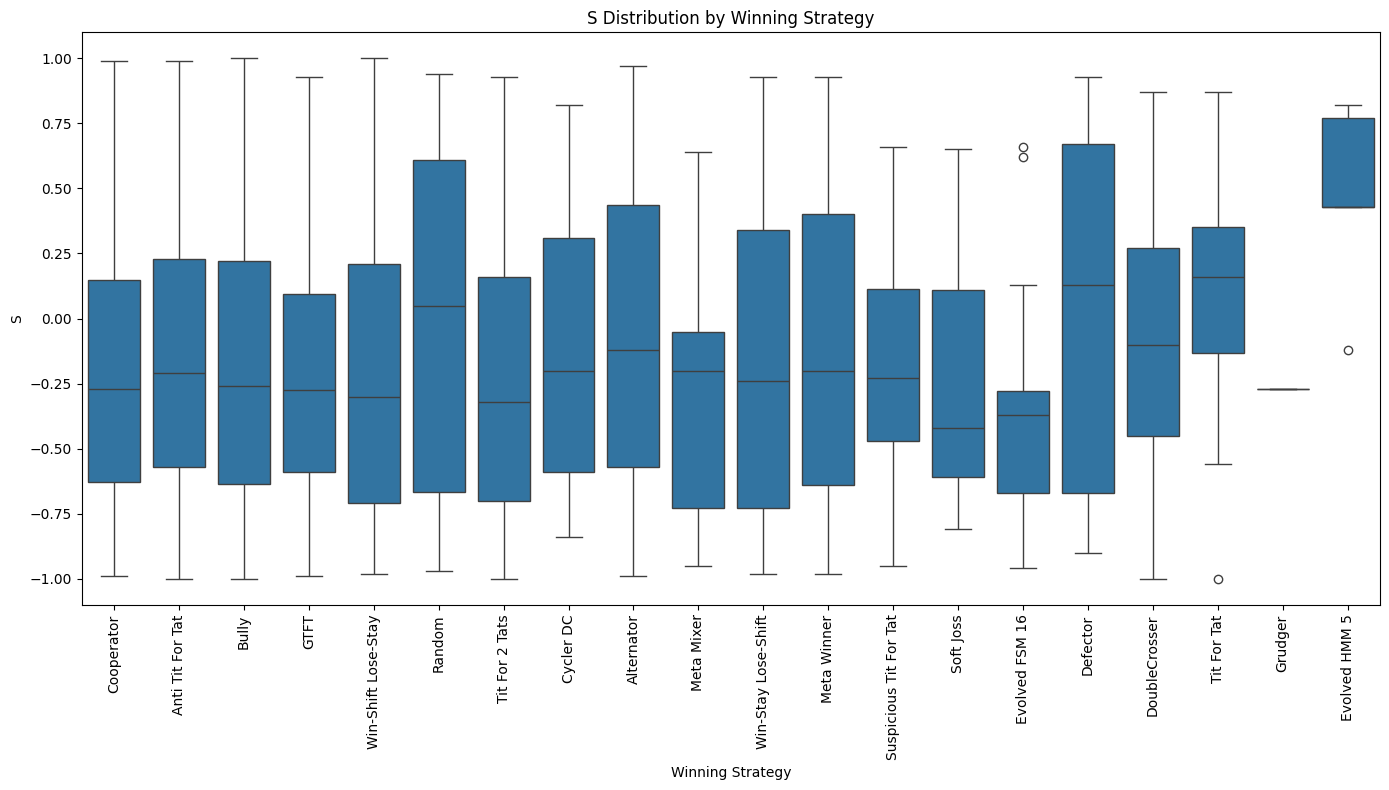

Saved plot: graphs/winner_S_boxplot.png


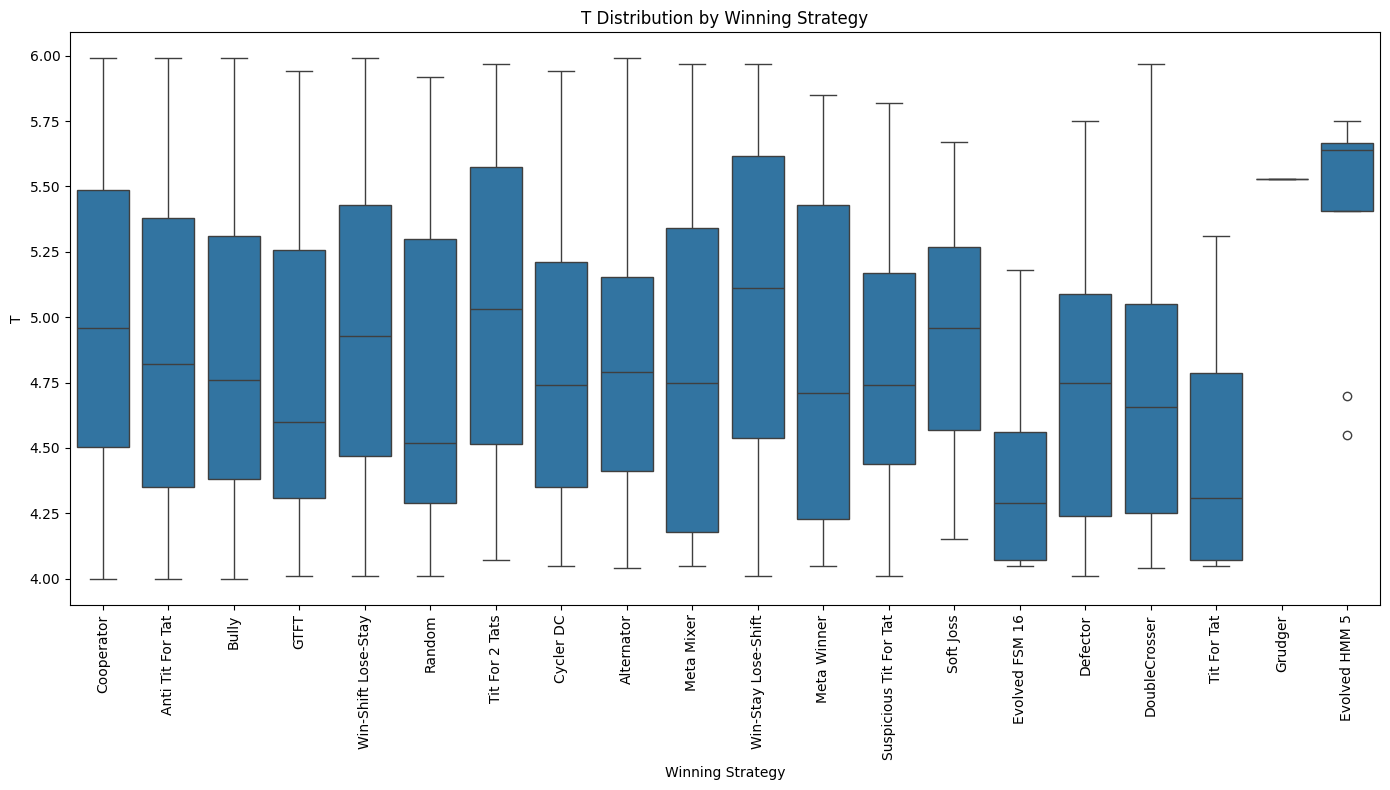

Saved plot: graphs/winner_T_boxplot.png


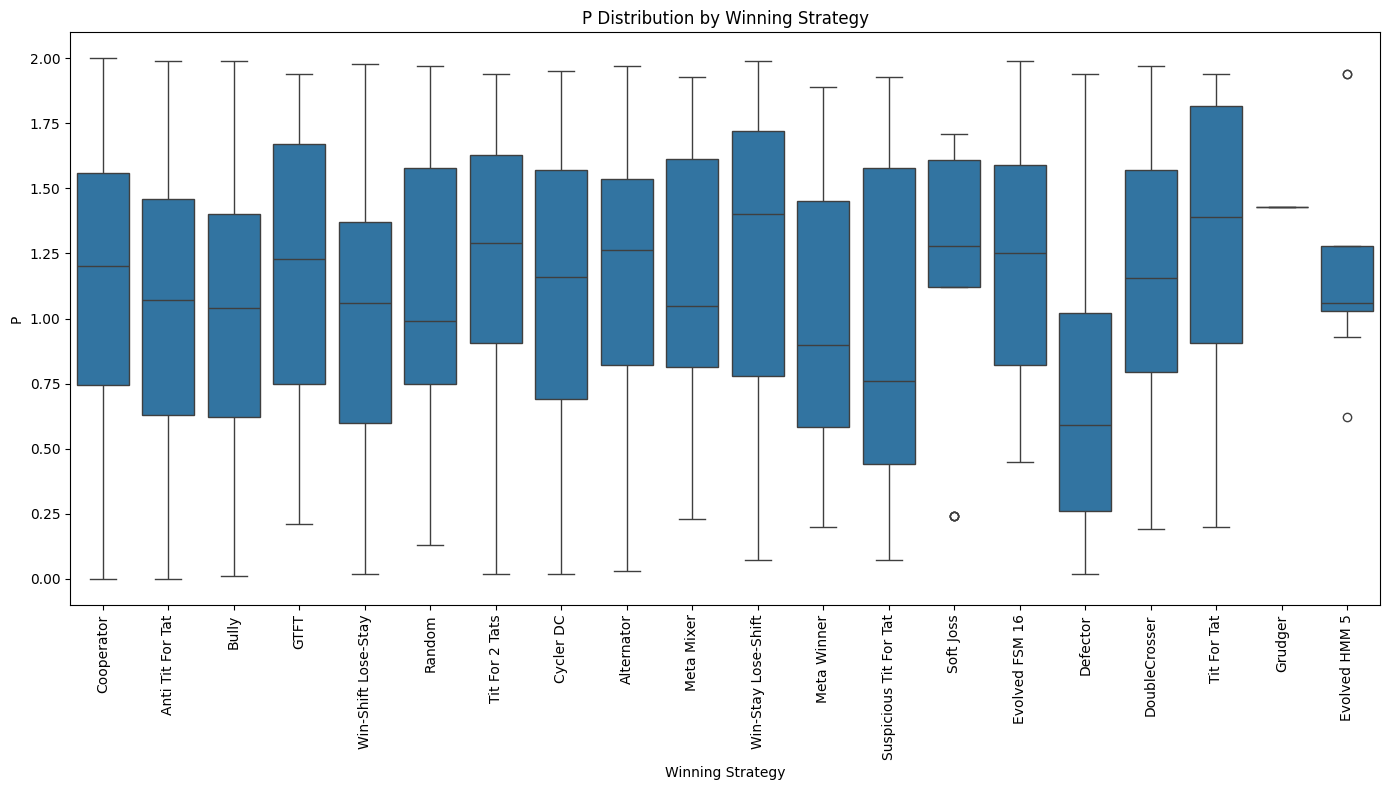

Saved plot: graphs/winner_P_boxplot.png


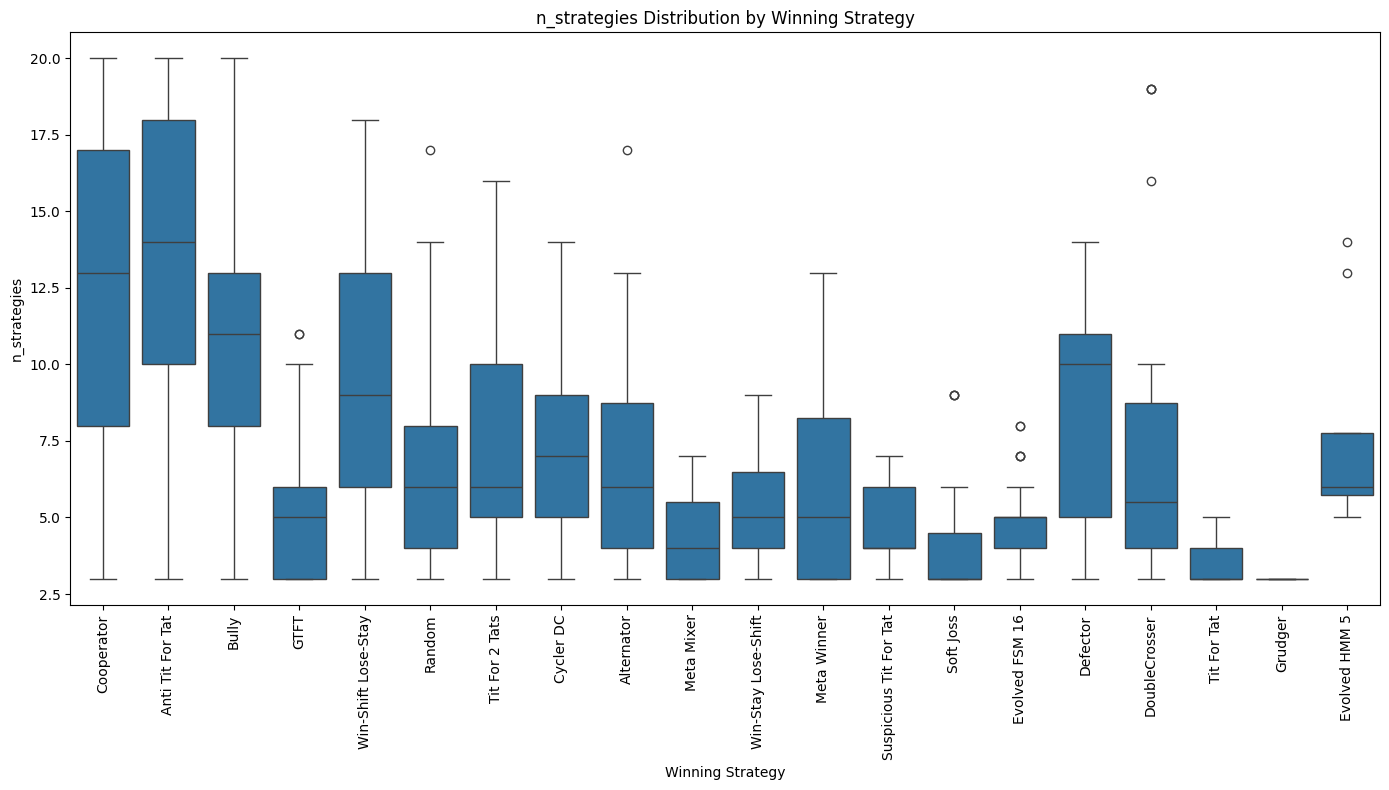

Saved plot: graphs/winner_n_strategies_boxplot.png


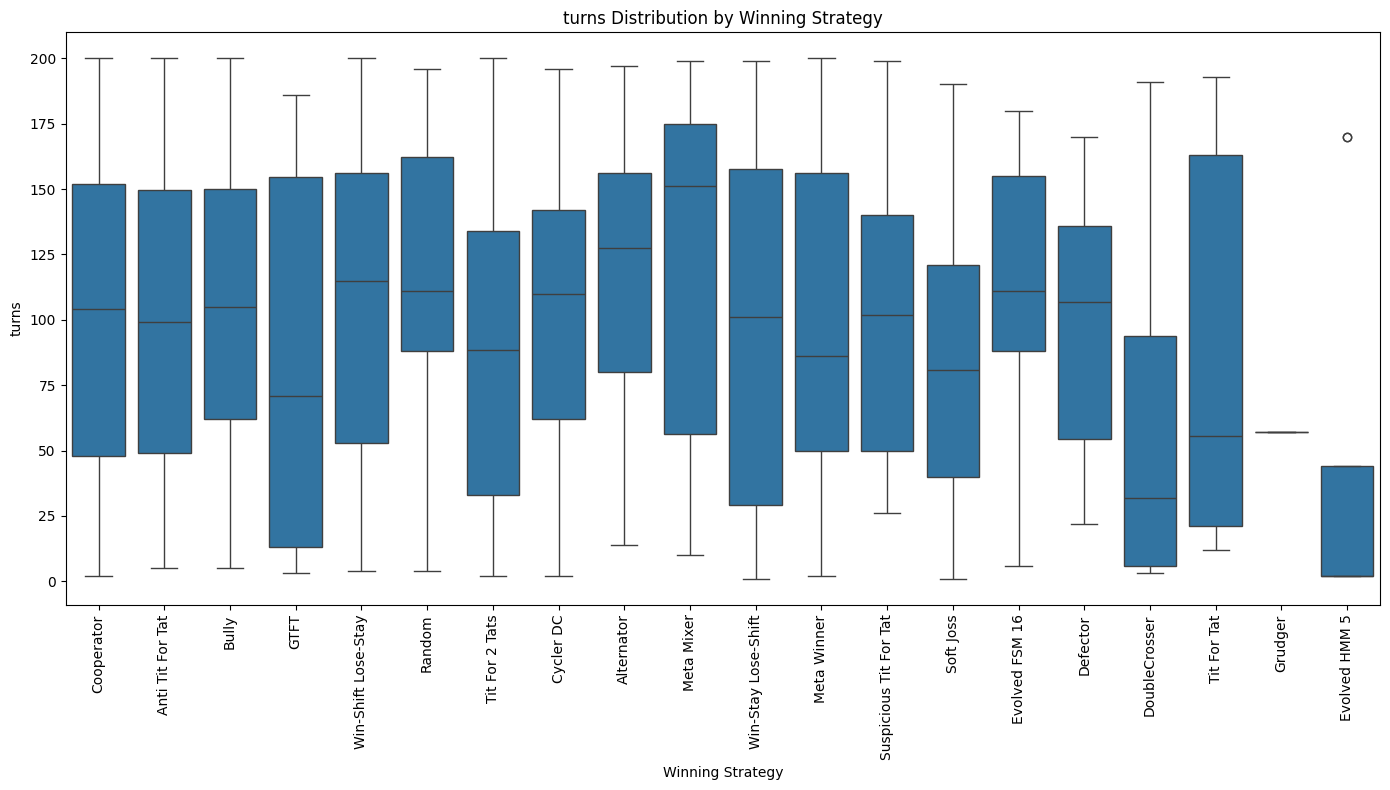

Saved plot: graphs/winner_turns_boxplot.png


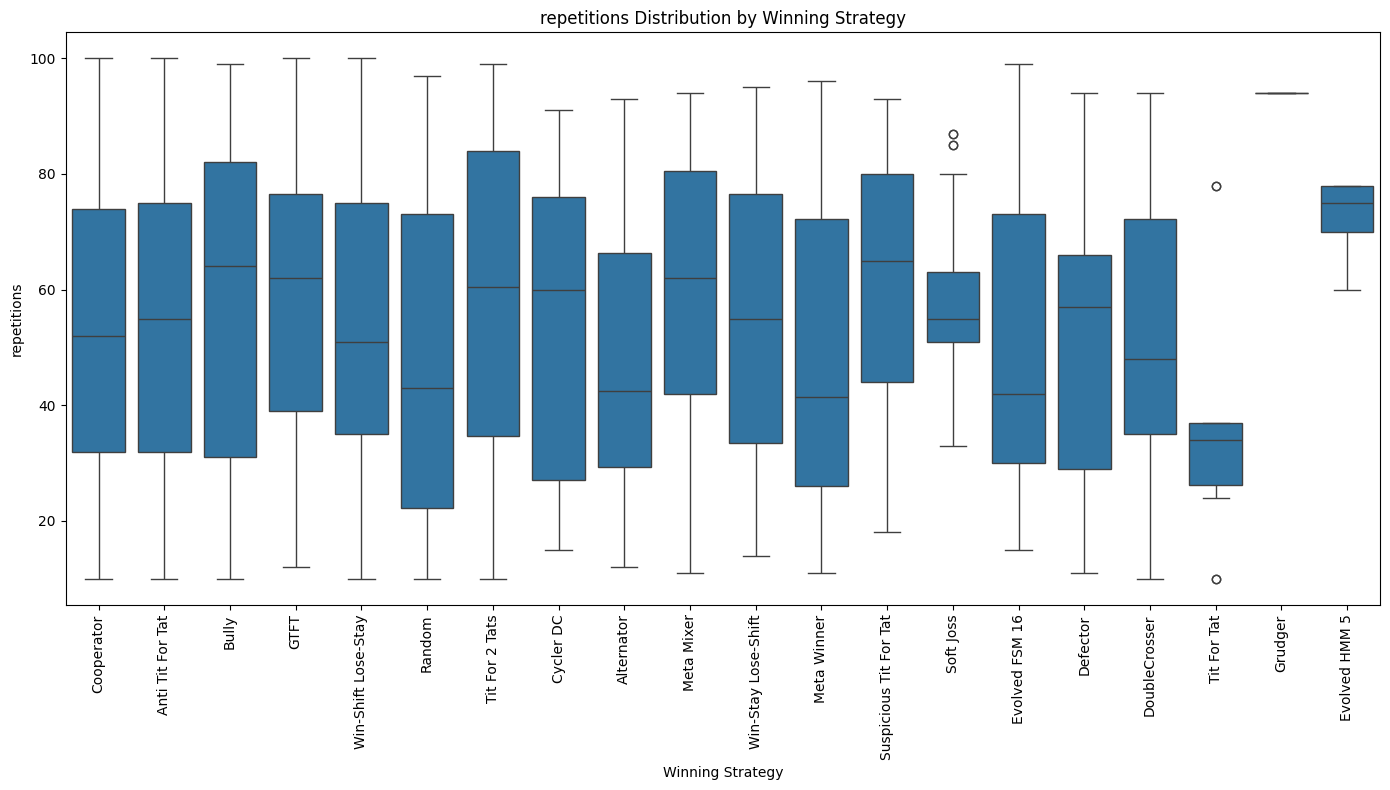

Saved plot: graphs/winner_repetitions_boxplot.png


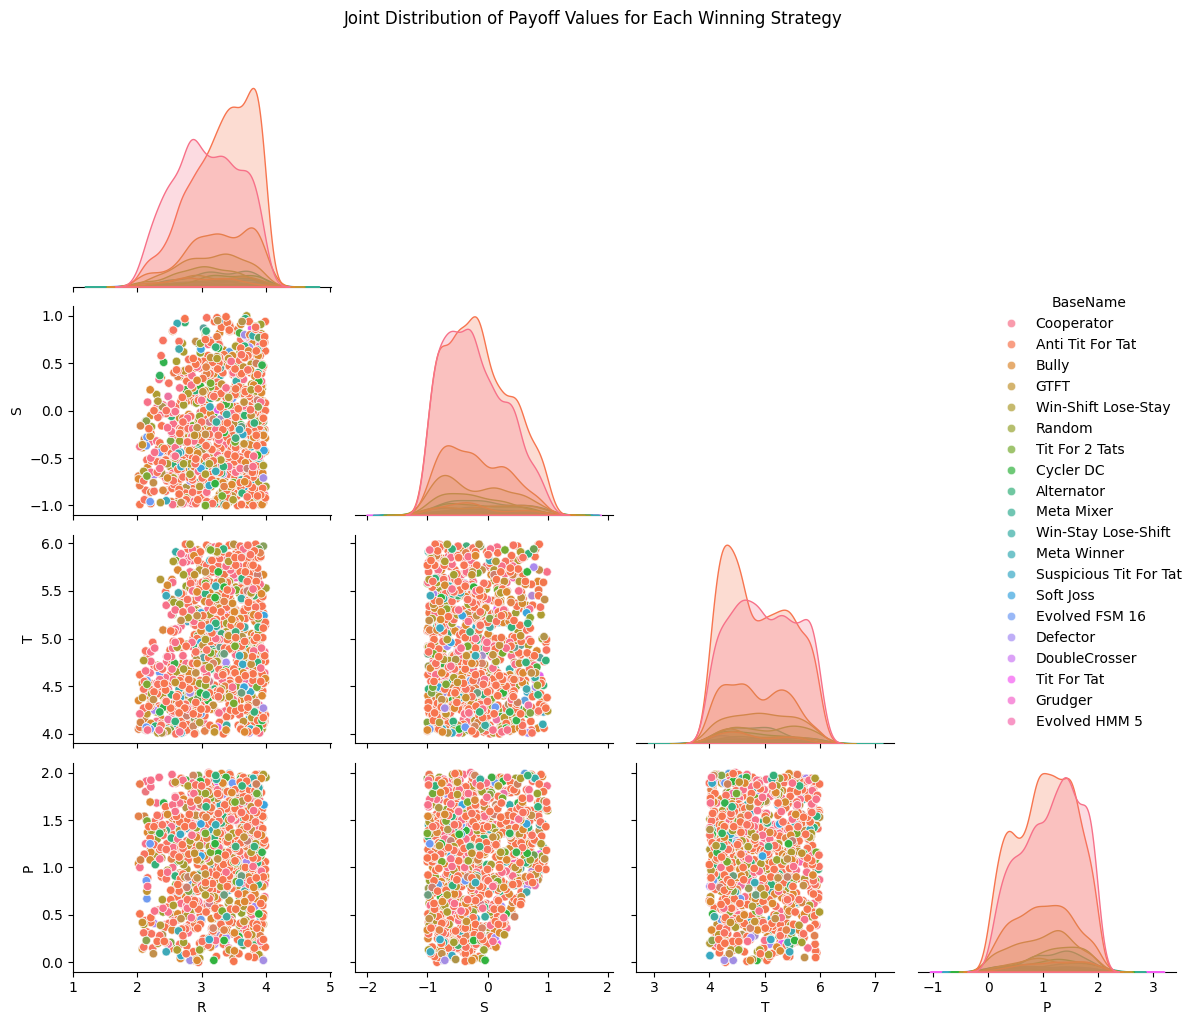

Saved plot: graphs/winner_payoff_pairplot.png


In [ ]:
# Advanced analysis and comparison plots
if dfs:
    all_data = pd.concat(dfs, ignore_index=True)
    all_data['BaseName'] = all_data['Name'].apply(extract_base_name)
    # Boxplot: Score distribution per strategy per tournament type
    if 'BaseName' in all_data.columns and 'normalized_rank' in all_data.columns and 'tournament_type' in all_data.columns:
        plt.figure(figsize=(16, 8))
        # Group by BaseName and tournament_type, not by all columns
        sns.boxplot(data=all_data, x='BaseName', y='normalized_rank', hue='tournament_type')
        plt.title("Normalized Rank Distribution per Strategy Across Tournament Types")
        plt.ylabel("Normalized Rank")
        plt.xlabel("Strategy")
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()
        #plt.savefig("graphs/score_distribution_boxplot.png")
        plt.close()
        print("Saved plot: graphs/score_distribution_boxplot.png")
  
# Grouped barplot: Median Normalized Rank per strategy per tournament type
        median_scores = all_data.groupby(['BaseName', 'tournament_type'])['normalized_rank'].median().reset_index()
        plt.figure(figsize=(16, 8))
        sns.barplot(data=median_scores, x='BaseName', y='normalized_rank', hue='tournament_type')
        plt.title("Median Normalized Rank per Strategy Across Tournament Types")
        plt.ylabel("Median Normalized Rank")
        plt.xlabel("Strategy")
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()
        #plt.savefig("graphs/mean_score_comparison.png")
        plt.close()
        print("Saved plot: graphs/median_score_comparison.png")
    else:
        print("Required columns not found for advanced plots")

        # Correlation heatmap of numeric variables
        numeric_cols = ['normalized_rank', 'Cooperation_rating', 'noise', 'prob_end', 'repetitions', 'turns', 'n_strategies']
        corr = all_data[numeric_cols].corr()
        plt.figure(figsize=(10, 8))
        sns.heatmap(corr, annot=True, cmap='coolwarm')
        plt.title('Correlation Matrix of Tournament Variables')
        plt.tight_layout()
        plt.show()
        #plt.savefig('graphs/correlation_heatmap.png')
        plt.close()
        print('Saved plot: graphs/correlation_heatmap.png')

        # Scatter plot: Normalized Rank vs. Noise by Strategy (use BaseName)
        plt.figure(figsize=(14, 8))
        sns.scatterplot(data=all_data, x='noise', y='normalized_rank', hue='BaseName', alpha=0.7)
        plt.title('Normalized Rank vs. Noise by Strategy')
        plt.ylabel('Normalized Rank')
        plt.xlabel('Noise')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()
        #plt.savefig('graphs/score_vs_noise.png')
        plt.close()
        print('Saved plot: graphs/score_vs_noise.png')

        # Barplot: Number of wins (highest Normalized Rank) per strategy (use BaseName)
        win_counts = all_data.loc[all_data.groupby(['tournament_type', 'Rank'])['normalized_rank'].idxmax()]
        win_counts['BaseName'] = win_counts['Name'].apply(extract_base_name)
        win_summary = win_counts['BaseName'].value_counts().sort_values(ascending=False)
        plt.figure(figsize=(12, 6))
        sns.barplot(x=win_summary.index, y=win_summary.values)
        plt.title('Number of Tournament Wins per Strategy (Highest Normalized Rank)')
        plt.ylabel('Number of Wins')
        plt.xlabel('Strategy')
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()
        #plt.savefig('graphs/strategy_win_counts.png')
        plt.close()
        print('Saved plot: graphs/strategy_win_counts.png')

        # Scatter plot: Cooperation vs. Normalized Rank (use BaseName)
        plt.figure(figsize=(12, 8))
        sns.scatterplot(data=all_data, x='Cooperation_rating', y='normalized_rank', hue='BaseName', alpha=0.7)
        plt.title('Cooperation Rating vs. Normalized Rank by Strategy')
        plt.xlabel('Cooperation Rating')
        plt.ylabel('Normalized Rank')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()
        #plt.savefig('graphs/cooperation_vs_score.png')
        plt.close()
        print('Saved plot: graphs/cooperation_vs_score.png')

        # Parameter sensitivity: Score vs. n_strategies (use BaseName)
        plt.figure(figsize=(12, 8))
        sns.scatterplot(data=all_data, x='n_strategies', y='normalized_rank', hue='BaseName', alpha=0.7)
        plt.title('Normalized Rank vs. Number of Strategies in Tournament')
        plt.xlabel('Number of Strategies')
        plt.ylabel('Normalized Rank')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()
        #plt.savefig('graphs/score_vs_n_strategies.png')
        plt.close()
        print('Saved plot: graphs/score_vs_n_strategies.png')

        # Robustness: Boxplot of Normalized Rank Std Dev per Strategy (use BaseName)
        score_std = all_data.groupby('BaseName')['normalized_rank'].std().sort_values(ascending=False)
        plt.figure(figsize=(12, 6))
        sns.barplot(x=score_std.index, y=score_std.values)
        plt.title('Score Standard Deviation per Strategy (Robustness)')
        plt.ylabel('Std Dev of Normalized Rank')
        plt.xlabel('Strategy')
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()
        #plt.savefig('graphs/score_std_per_strategy.png')
        plt.close()
        print('Saved plot: graphs/score_std_per_strategy.png')

        # Cooperation vs. Score by Tournament Type (FacetGrid, use BaseName)
        g = sns.FacetGrid(all_data, col='tournament_type', col_wrap=2, height=5, sharex=True, sharey=True)
        g.map_dataframe(sns.scatterplot, x='Cooperation_rating', y='normalized_rank', hue='BaseName', alpha=0.7)
        g.add_legend()
        g.set_axis_labels('Cooperation Rating', 'Normalized Rank')
        g.fig.suptitle('Cooperation vs. Normalized Rank by Tournament Type', y=1.02)
        plt.tight_layout()
        plt.show()
        g.savefig('graphs/cooperation_vs_score_facet.png')
        plt.close()
        print('Saved plot: graphs/cooperation_vs_score_facet.png')

        # --- Advanced: Pairwise Matchup Matrix (Heatmap) ---
    if 'Name' in all_data.columns and 'Opponent' in all_data.columns and 'normalized_rank' in all_data.columns:
        # Pivot to get average score for each (strategy, opponent) pair
        matchup = all_data.pivot_table(index='Name', columns='Opponent', values='normalized_rank', aggfunc='mean')
        plt.figure(figsize=(14, 12))
        sns.heatmap(matchup, annot=False, cmap='viridis')
        plt.title('Pairwise Matchup: Average Normalized Rank (Strategy vs. Opponent)')
        plt.ylabel('Strategy')
        plt.xlabel('Opponent')
        plt.tight_layout()
        plt.show()
        #plt.savefig('graphs/pairwise_matchup_heatmap.png')
        plt.close()
        print('Saved plot: graphs/pairwise_matchup_heatmap.png')
    else:
        print('Pairwise matchup matrix skipped: required columns (Name, Opponent, normalized_rank) not found.')

    # --- Advanced: Clustering of Strategies (Hierarchical) ---
    if 'BaseName' in all_data.columns and 'normalized_rank' in all_data.columns and 'tournament_type' in all_data.columns:
        # Create a matrix: rows=base strategies, columns=tournament types, values=mean Normalized Rank
        perf_matrix = all_data.pivot_table(index='BaseName', columns='tournament_type', values='normalized_rank', aggfunc='mean').fillna(0)
        from scipy.cluster.hierarchy import linkage, dendrogram
        import numpy as np
        plt.figure(figsize=(10, 6))
        linkage_matrix = linkage(perf_matrix, method='ward')
        dendrogram(linkage_matrix, labels=perf_matrix.index, leaf_rotation=90)
        plt.title('Hierarchical Clustering of Strategies by Performance')
        plt.ylabel('Distance')
        plt.tight_layout()
        plt.show()
       # plt.savefig('graphs/strategy_clustering_dendrogram.png')
        plt.close()
        print('Saved plot: graphs/strategy_clustering_dendrogram.png')
    else:
        print('Strategy clustering skipped: required columns not found.')

        # --- Correlation between tournament variables and winning strategies ---
    # For each run and tournament type, find the winning strategy (highest mean Normalized Rank)
    if 'BaseName' in all_data.columns and 'normalized_rank' in all_data.columns and 'run' in all_data.columns and 'tournament_type' in all_data.columns:
        # Find the winner for each run and tournament type
        winners = all_data.loc[all_data.groupby(['run', 'tournament_type'])['normalized_rank'].idxmax()]
        # Select relevant columns for correlation
        corr_vars = ['noise', 'prob_end', 'R', 'S', 'T', 'P', 'n_strategies', 'turns', 'repetitions']
        # Encode winning strategy as categorical codes for correlation
        winners = winners.copy()
        winners['WinnerCode'] = winners['BaseName'].astype('category').cat.codes
        # Compute correlation matrix
        corr = winners[corr_vars + ['WinnerCode']].corr()
        plt.figure(figsize=(10, 8))
        sns.heatmap(corr, annot=True, cmap='coolwarm')
        plt.title('Correlation between Tournament Variables and Winning Strategy (code)')
        plt.tight_layout()
        plt.show()
        #plt.savefig('graphs/winner_variable_correlation_heatmap.png')
        plt.close()
        print('Saved plot: graphs/winner_variable_correlation_heatmap.png')
    else:
        print('Could not compute winner-variable correlation: required columns not found.')

    # --- Boxplots: Each variable vs. Winning Strategy ---
    if 'BaseName' in all_data.columns and 'normalized_rank' in all_data.columns and 'run' in all_data.columns and 'tournament_type' in all_data.columns:
        winners = all_data.loc[all_data.groupby(['run', 'tournament_type'])['normalized_rank'].idxmax()]
        corr_vars = ['noise', 'prob_end', 'R', 'S', 'T', 'P', 'n_strategies', 'turns', 'repetitions']
        for var in corr_vars:
            if var in winners.columns:
                plt.figure(figsize=(14, 8))
                sns.boxplot(data=winners, x='BaseName', y=var)
                plt.title(f'{var} Distribution by Winning Strategy')
                plt.xlabel('Winning Strategy')
                plt.ylabel(var)
                plt.xticks(rotation=90)
                plt.tight_layout()
                plt.show()
               # plt.savefig(f'graphs/winner_{var}_boxplot.png')
                plt.close()
                print(f'Saved plot: graphs/winner_{var}_boxplot.png')
    else:
        print('Could not create variable-vs-winner boxplots: required columns not found.')

    # --- Pairplot: Joint distribution of payoffs for each winning strategy ---
    if 'BaseName' in all_data.columns and 'normalized_rank' in all_data.columns and 'run' in all_data.columns and 'tournament_type' in all_data.columns:
        winners = all_data.loc[all_data.groupby(['run', 'tournament_type'])['normalized_rank'].idxmax()]
        payoff_vars = ['R', 'S', 'T', 'P']
        if all(var in winners.columns for var in payoff_vars):
            import seaborn as sns
            sns.pairplot(winners, vars=payoff_vars, hue='BaseName', corner=True, plot_kws={'alpha':0.7})
            plt.suptitle('Joint Distribution of Payoff Values for Each Winning Strategy', y=1.02)
            plt.tight_layout()
            plt.show()
            #plt.savefig('graphs/winner_payoff_pairplot.png')
            plt.close()
            print('Saved plot: graphs/winner_payoff_pairplot.png')
        else:
            print('Could not create payoff pairplot: some payoff columns missing.')
    else:
        print('Could not create payoff pairplot: required columns not found.')


/home/kiko/Desktop/aasma/AASMA/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/kiko/Desktop/aasma/AASMA/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/kiko/Desktop/aasma/AASMA/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/ho

Saved classification report: graphs/winner_by_rank_multinomial_logit_classification_report.txt


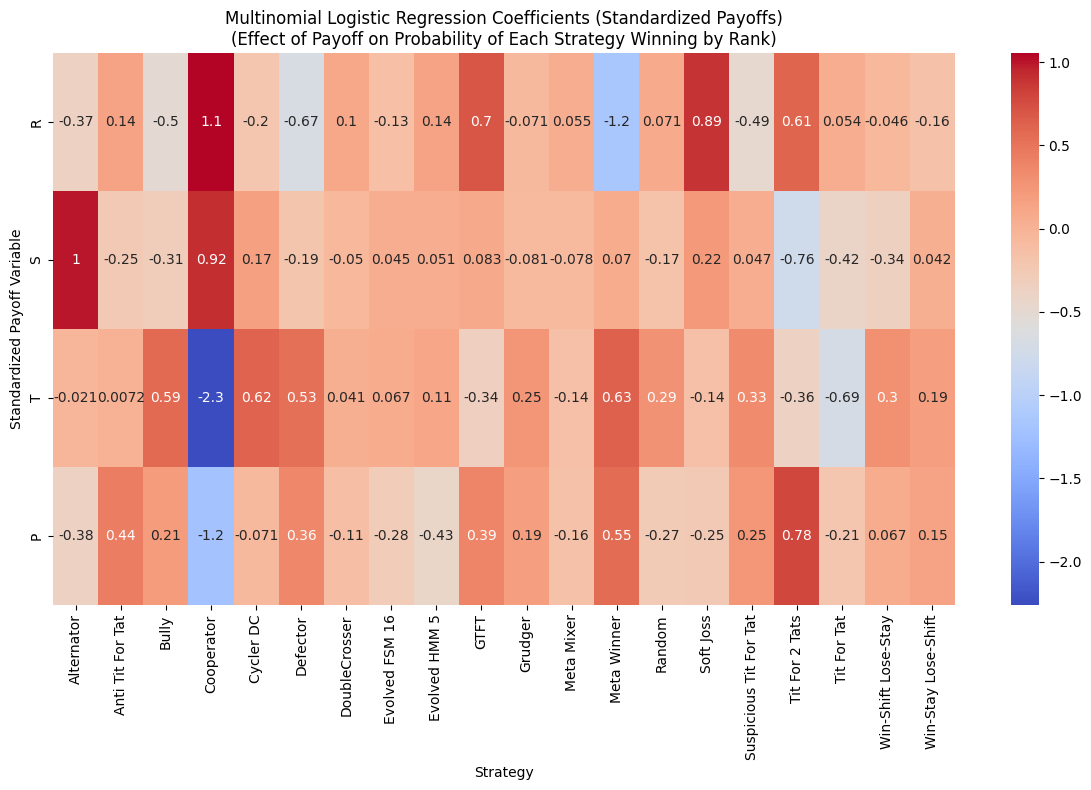

Saved plot: graphs/winner_by_rank_multinomial_logit_coef_heatmap.png


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

# Select winners by minimum Rank per run and tournament_type
if 'BaseName' in all_data.columns and 'Rank' in all_data.columns and 'run' in all_data.columns and 'tournament_type' in all_data.columns:
    winners_by_rank = all_data.loc[all_data.groupby(['run', 'tournament_type'])['Rank'].idxmin()]
    payoff_vars = ['R', 'S', 'T', 'P']
    if all(var in winners_by_rank.columns for var in payoff_vars):
        # Filter out rare strategies (fewer than 5 wins)
        counts = winners_by_rank['BaseName'].value_counts()
        common_strats = counts[counts >= 5].index
        winners_by_rank = winners_by_rank[winners_by_rank['BaseName'].isin(common_strats)].copy()
        # Standardize payoffs
        scaler = StandardScaler()
        X_rank = scaler.fit_transform(winners_by_rank[payoff_vars])
        y_rank = winners_by_rank['BaseName']
        # Fit multinomial logistic regression
        clf_rank = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=500)
        clf_rank.fit(X_rank, y_rank)
        # Save classification report
        y_pred_rank = clf_rank.predict(X_rank)
        report_rank = classification_report(y_rank, y_pred_rank)
        with open('graphs/winner_by_rank_multinomial_logit_classification_report.txt', 'w') as f:
            f.write(report_rank)
        print('Saved classification report: graphs/winner_by_rank_multinomial_logit_classification_report.txt')
        # Plot coefficients as heatmap
        coef_rank = clf_rank.coef_.T
        plt.figure(figsize=(12, 8))
        sns.heatmap(coef_rank, annot=True, cmap='coolwarm', xticklabels=clf_rank.classes_, yticklabels=payoff_vars)
        plt.title('Multinomial Logistic Regression Coefficients (Standardized Payoffs)\n(Effect of Payoff on Probability of Each Strategy Winning by Rank)')
        plt.ylabel('Standardized Payoff Variable')
        plt.xlabel('Strategy')
        plt.tight_layout()
        plt.show()
        plt.close()
        print('Saved plot: graphs/winner_by_rank_multinomial_logit_coef_heatmap.png')
    else:
        print('Could not run regression: some payoff columns missing.')
else:
    print('Could not run regression: required columns not found.')


Saved classification report: graphs/winner_multinomial_logit_classification_report.txt


/home/kiko/Desktop/aasma/AASMA/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/kiko/Desktop/aasma/AASMA/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/kiko/Desktop/aasma/AASMA/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/ho

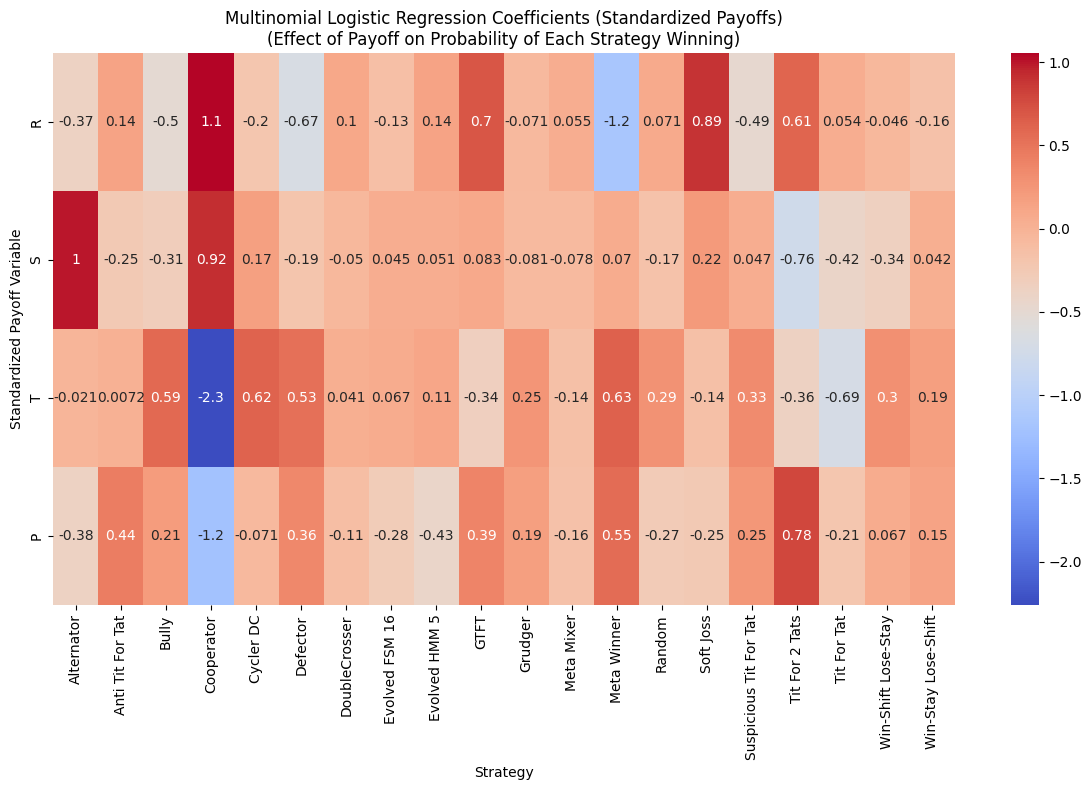

Saved plot: graphs/winner_multinomial_logit_coef_heatmap.png


In [ ]:
 # --- Multinomial Logistic Regression (robust, standardized, filtered) ---
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import numpy as np
# Prepare winners data
if 'BaseName' in all_data.columns and 'Median_score' in all_data.columns and 'run' in all_data.columns and 'tournament_type' in all_data.columns:
    winners = all_data.loc[all_data.groupby(['run', 'tournament_type'])['Median_score'].idxmax()]
    payoff_vars = ['R', 'S', 'T', 'P']
    if all(var in winners.columns for var in payoff_vars):
        # Filter out rare strategies (fewer than 5 wins)
        counts = winners['BaseName'].value_counts()
        common_strats = counts[counts >= 5].index
        winners = winners[winners['BaseName'].isin(common_strats)].copy()
        # Standardize payoffs
        scaler = StandardScaler()
        X = scaler.fit_transform(winners[payoff_vars])
        y = winners['BaseName']
        # Fit multinomial logistic regression
        clf = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=500)
        clf.fit(X, y)
        # Save classification report
        y_pred = clf.predict(X)
        report = classification_report(y, y_pred)
        with open('graphs/winner_multinomial_logit_classification_report.txt', 'w') as f:
            f.write(report)
        print('Saved classification report: graphs/winner_multinomial_logit_classification_report.txt')
        # Plot coefficients as heatmap
        import matplotlib.pyplot as plt
        import seaborn as sns
        coef = clf.coef_.T  # shape: (payoff_vars, n_strategies)
        plt.figure(figsize=(12, 8))
        sns.heatmap(coef, annot=True, cmap='coolwarm', xticklabels=clf.classes_, yticklabels=payoff_vars)
        plt.title('Multinomial Logistic Regression Coefficients (Standardized Payoffs)\n(Effect of Payoff on Probability of Each Strategy Winning)')
        plt.ylabel('Standardized Payoff Variable')
        plt.xlabel('Strategy')
        plt.tight_layout()
        #plt.savefig('graphs/winner_multinomial_logit_coef_heatmap.png')
        plt.show()
        plt.close()
        print('Saved plot: graphs/winner_multinomial_logit_coef_heatmap.png')
    else:
        print('Could not run regression: some payoff columns missing.')
else:
    print('Could not run regression: required columns not found.')